# Análise Long Neck NENO — Ambev Case
### Gráficos de Análise Univariada


In [115]:
# Importações e configuração visual padrão
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'font.size': 11
})

# Paleta customizada Ambev
AMBEV_YELLOW = '#FFB800'
AMBEV_DARK = '#1A1A1A'
AMBEV_BLUE = '#4169E1'
AMBEV_RED = '#C0392B'
AMBEV_GREEN = '#27AE60'


## 1. Carregamento dos Dados
Leitura de todas as abas do arquivo Excel convertido (.xlsx).

In [116]:
# Carrega todas as abas relevantes do arquivo
file_path = '/Users/gustavopacheco/Downloads/PS JR/Analise_LongNeck_WSNP_-_Sem_repostas.xlsx'

cenario_br = pd.read_excel(file_path, sheet_name='Cenário atual BR', header=None, engine='calamine')
custos = pd.read_excel(file_path, sheet_name='Custos de transferência', header=None, engine='calamine')
producao_pcp = pd.read_excel(file_path, sheet_name='Produção PCP', header=None, engine='calamine')
transf_prog = pd.read_excel(file_path, sheet_name='Transferências Programadas', header=None, engine='calamine')
cenario_div = pd.read_excel(file_path, sheet_name='Cenário Divulgado', header=None, engine='calamine')
cenario_novo = pd.read_excel(file_path, sheet_name='Cenário com Nova Demanda', header=None, engine='calamine')

print("Abas carregadas com sucesso!")
for name, df in [('Cenário BR', cenario_br), ('Custos', custos), 
                  ('Produção PCP', producao_pcp), ('Transf. Prog.', transf_prog),
                  ('Cenário Divulgado', cenario_div), ('Cenário Nova Demanda', cenario_novo)]:
    print(f"  {name}: {df.shape[0]} linhas x {df.shape[1]} colunas")

Abas carregadas com sucesso!
  Cenário BR: 25 linhas x 24 colunas
  Custos: 23 linhas x 5 colunas
  Produção PCP: 16 linhas x 10 colunas
  Transf. Prog.: 8 linhas x 11 colunas
  Cenário Divulgado: 49 linhas x 48 colunas
  Cenário Nova Demanda: 49 linhas x 48 colunas


## 2. Demanda por Região — Cenário Brasil (Janeiro)
Distribuição da demanda total de Long Neck entre as regionais do Brasil, destacando o peso do NENO.


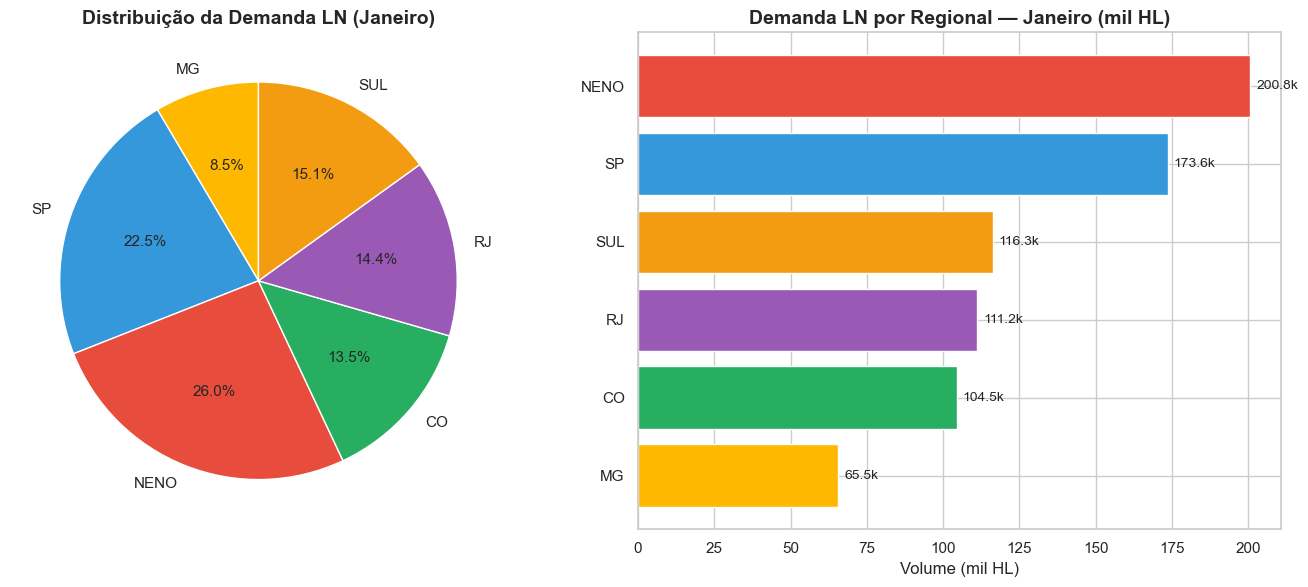

In [117]:
# Cenário atual BR — Demanda Janeiro (lido da aba 'Cenário atual BR')
regioes = ['MG', 'SP', 'NENO', 'CO', 'RJ', 'SUL']
demanda_jan = [
    cenario_br.iloc[5, 3],   # MG
    cenario_br.iloc[6, 3],   # SP
    cenario_br.iloc[7, 3],   # NENO
    cenario_br.iloc[8, 3],   # CO
    cenario_br.iloc[9, 3],   # RJ
    cenario_br.iloc[10, 3],  # SUL
]

colors = [AMBEV_YELLOW, '#3498DB', '#E74C3C', AMBEV_GREEN, '#9B59B6', '#F39C12']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

wedges, texts, autotexts = ax1.pie(demanda_jan, labels=regioes, autopct='%1.1f%%',
                                     colors=colors, startangle=90, textprops={'fontsize': 11})
ax1.set_title('Distribuição da Demanda LN (Janeiro)', fontsize=14, fontweight='bold')

sorted_idx = np.argsort(demanda_jan)
ax2.barh([regioes[i] for i in sorted_idx], [demanda_jan[i]/1000 for i in sorted_idx],
         color=[colors[i] for i in sorted_idx], edgecolor='white')
ax2.set_xlabel('Volume (mil HL)')
ax2.set_title('Demanda LN por Regional — Janeiro (mil HL)', fontsize=14, fontweight='bold')
for i, idx in enumerate(sorted_idx):
    ax2.text(demanda_jan[idx]/1000 + 2, i, f'{demanda_jan[idx]/1000:.1f}k', va='center', fontsize=10)

plt.tight_layout()
plt.show()


## 4. Custos de Transferência e Produção
Comparação entre custo de transferência (SP → NE via cabotagem), MACO e custo de produção por SKU.


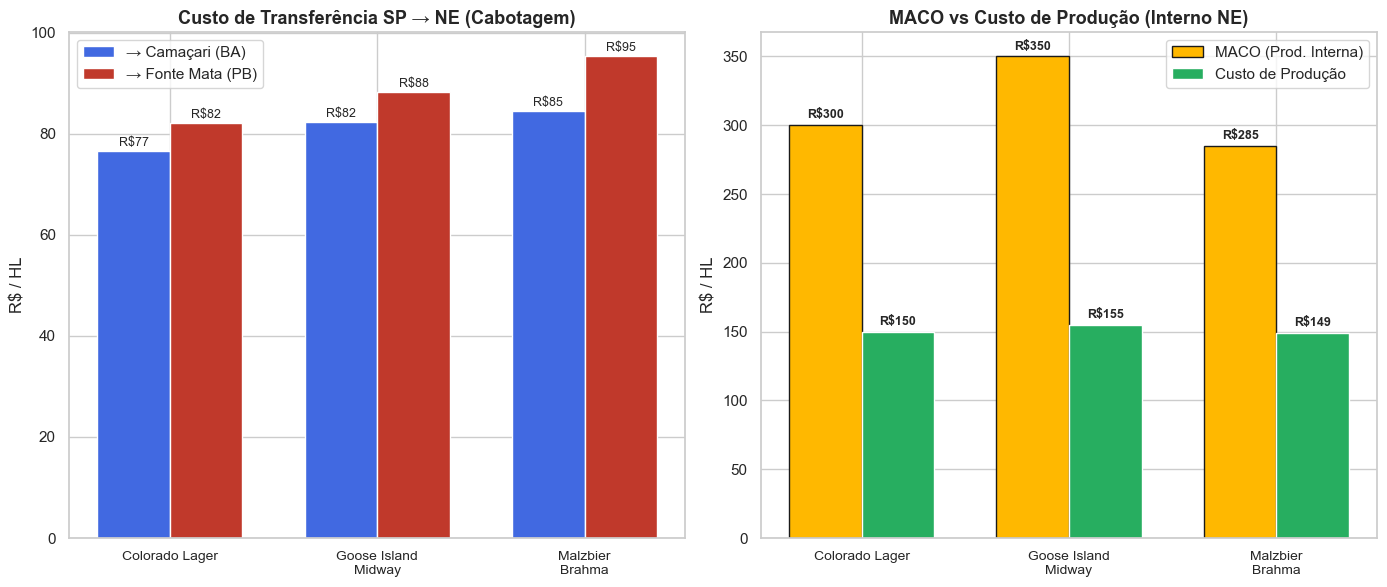

In [119]:
# Custos — lidos da aba 'Custos de transferência'
skus_short = ['Colorado Lager', 'Goose Island\nMidway', 'Malzbier\nBrahma']

transf_camacari  = [custos.iloc[3, 4], custos.iloc[5, 4], custos.iloc[6, 4]]  # → Camaçari
transf_fonte_mata = [custos.iloc[4, 4], custos.iloc[7, 4], custos.iloc[8, 4]]  # → Fonte Mata
maco      = [custos.iloc[13, 4], custos.iloc[14, 4], custos.iloc[15, 4]]
custo_prod = [custos.iloc[20, 4], custos.iloc[21, 4], custos.iloc[22, 4]]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
x = np.arange(3)
w = 0.35

ax1.bar(x - w/2, transf_camacari,  w, label='→ Camaçari (BA)', color=AMBEV_BLUE)
ax1.bar(x + w/2, transf_fonte_mata, w, label='→ Fonte Mata (PB)', color=AMBEV_RED)
ax1.set_xticks(x); ax1.set_xticklabels(skus_short, fontsize=10)
ax1.set_ylabel('R$ / HL')
ax1.set_title('Custo de Transferência SP → NE (Cabotagem)', fontsize=13, fontweight='bold')
ax1.legend()
for i in range(3):
    ax1.text(i - w/2, transf_camacari[i]  + 1, f'R${transf_camacari[i]:.0f}',  ha='center', fontsize=9)
    ax1.text(i + w/2, transf_fonte_mata[i] + 1, f'R${transf_fonte_mata[i]:.0f}', ha='center', fontsize=9)

ax2.bar(x - w/2, maco,       w, label='MACO (Prod. Interna)', color=AMBEV_YELLOW, edgecolor=AMBEV_DARK)
ax2.bar(x + w/2, custo_prod, w, label='Custo de Produção',    color=AMBEV_GREEN)
ax2.set_xticks(x); ax2.set_xticklabels(skus_short, fontsize=10)
ax2.set_ylabel('R$ / HL')
ax2.set_title('MACO vs Custo de Produção (Interno NE)', fontsize=13, fontweight='bold')
ax2.legend()
for i in range(3):
    ax2.text(i - w/2, maco[i]       + 5, f'R${maco[i]:.0f}',       ha='center', fontsize=9, fontweight='bold')
    ax2.text(i + w/2, custo_prod[i] + 5, f'R${custo_prod[i]:.0f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()
